# Build & Opponent Analysis

Weapon / hullmod popularity, opponent difficulty, flux allocation, and
parameter importance for a single experiment run.

Set `EXPERIMENT_DIR` via env var (nbconvert) or edit the loader cell.

In [1]:
import json
import os
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent / "src"))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import optuna
from optuna.trial import TrialState

# EXPERIMENT_DIR may be overridden via env var (used by nbconvert for batch execution).
EXPERIMENT_DIR = Path(os.environ.get(
    "EXPERIMENT_DIR",
    "../experiments/hammerhead-twfe-2026-04-13",
)).resolve()

db_files = sorted(EXPERIMENT_DIR.glob("*.db"))
if not db_files:
    raise FileNotFoundError(f"No .db file in {EXPERIMENT_DIR}")
# Prefer a name matching the directory (e.g. hammerhead.db over hammerhead_snapshot_0837.db).
preferred = [p for p in db_files if "_" not in p.stem]
STUDY_DB = preferred[0] if preferred else db_files[0]

log_files = sorted(EXPERIMENT_DIR.glob("evaluation_log*.jsonl"))
if not log_files:
    raise FileNotFoundError(f"No evaluation_log*.jsonl in {EXPERIMENT_DIR}")
preferred_log = [p for p in log_files if p.name == "evaluation_log.jsonl"]
EVAL_LOG = preferred_log[0] if preferred_log else log_files[0]

storage = f"sqlite:///{STUDY_DB}"
study_names = optuna.get_all_study_names(storage)
if len(study_names) != 1:
    raise RuntimeError(f"Expected 1 study in {STUDY_DB}, found {study_names}")
STUDY_NAME = study_names[0]

study = optuna.load_study(study_name=STUDY_NAME, storage=storage)
trials = study.trials

eval_entries = []
with open(EVAL_LOG) as f:
    for line in f:
        eval_entries.append(json.loads(line))

print(f"Experiment: {EXPERIMENT_DIR.name}")
print(f"Study: {STUDY_NAME}  ({STUDY_DB.name})")
print(f"Eval log: {EVAL_LOG.name}  ({len(eval_entries)} entries)")
print(f"Trials in study: {len(trials)}")
state_counts = pd.Series([t.state.name for t in trials]).value_counts().to_dict()
print(f"States: {state_counts}")

# Build-analysis specifics: completed-only eval entries + fitness threshold.
from collections import Counter

completed_entries = [e for e in eval_entries if not e["pruned"]]
fitness = np.array([e["fitness"] for e in completed_entries])
top_25_threshold = np.percentile(fitness, 75) if fitness.size else 0.0
top_mask = fitness >= top_25_threshold
bot_threshold = np.percentile(fitness, 25) if fitness.size else 0.0
bot_mask = fitness < bot_threshold
n_all = len(completed_entries)
n_top = int(top_mask.sum())
n_bot = int(bot_mask.sum())
print(f"Completed eval entries: {n_all}")
print(f"Top 25% threshold (fitness >= {top_25_threshold:.3f}): {n_top} builds")
print(f"Bottom 25% threshold (fitness < {bot_threshold:.3f}): {n_bot} builds")

/home/sdai/ClaudeCode/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Experiment: hammerhead-twfe-2026-04-13
Study: hammerhead  (hammerhead.db)
Eval log: evaluation_log.jsonl  (368 entries)
Trials in study: 899
States: {'COMPLETE': 839, 'PRUNED': 56, 'RUNNING': 4}
Completed eval entries: 313
Top 25% threshold (fitness >= 0.720): 79 builds
Bottom 25% threshold (fitness < 0.300): 78 builds


## Top 10 Builds

Full breakdown of highest-fitness builds with W/L/T (Timeout) per opponent.

In [2]:
def summarize(entry):
    results = entry["opponent_results"]
    tally = Counter(r["winner"] for r in results)
    w = tally.get("PLAYER", 0)
    l = tally.get("ENEMY", 0)
    t = tally.get("TIMEOUT", 0)
    s = tally.get("STOPPED", 0)
    return w, l, t, s

top_entries = sorted(completed_entries, key=lambda e: e["fitness"], reverse=True)[:10]
for i, e in enumerate(top_entries):
    build = e["build"]
    weapons = {slot: w for slot, w in build["weapon_assignments"].items() if w is not None}
    mods = build["hullmods"]
    w, l, t, s = summarize(e)
    raw = e.get("raw_fitness", float("nan"))
    print(f"#{i+1} fitness={e['fitness']:.4f}  raw={raw:.4f}  "
          f"trial {e['trial_number']} — W{w}/L{l}/T{t}/S{s}")
    print(f"   weapons: {', '.join(f'{slot}={wp}' for slot, wp in sorted(weapons.items()))}")
    print(f"   hullmods: {', '.join(sorted(mods)) or '(none)'}")
    print(f"   vents={build['flux_vents']}  caps={build['flux_capacitors']}")
    print()

#1 fitness=1.0000  raw=0.3606  trial 512 — W9/L0/T1/S0
   weapons: WS 004=sabot, WS 006=mininglaser, WS 007=lightmg, WS 008=vulcan
   hullmods: adaptiveshields, advancedoptics, assault_package, auxiliarythrusters, ballistic_rangefinder, fragment_coordinator, militarized_subsystems, reinforcedhull, shrouded_lens, shrouded_mantle
   vents=4  caps=4

#2 fitness=1.0000  raw=0.3931  trial 517 — W9/L0/T1/S0
   weapons: WS 004=sabot, WS 006=lightdualmg, WS 007=lightmg, WS 008=vulcan
   hullmods: adaptiveshields, advancedoptics, assault_package, auxiliarythrusters, ballistic_rangefinder, fragment_coordinator, militarized_subsystems, reinforcedhull, shrouded_lens, shrouded_mantle
   vents=2  caps=2

#3 fitness=1.0000  raw=0.4765  trial 574 — W9/L0/T1/S0
   weapons: WS 002=shredder, WS 003=atropos, WS 004=harpoon, WS 006=lrpdlaser, WS 007=lrpdlaser, WS 008=lightac
   hullmods: advancedshieldemitter, autorepair, auxiliary_fuel_tanks, escort_package, missleracks, neural_integrator, shrouded_lens, 

## Weapon Popularity

Top weapons across all builds vs the top-quartile slice, with enrichment ratios.

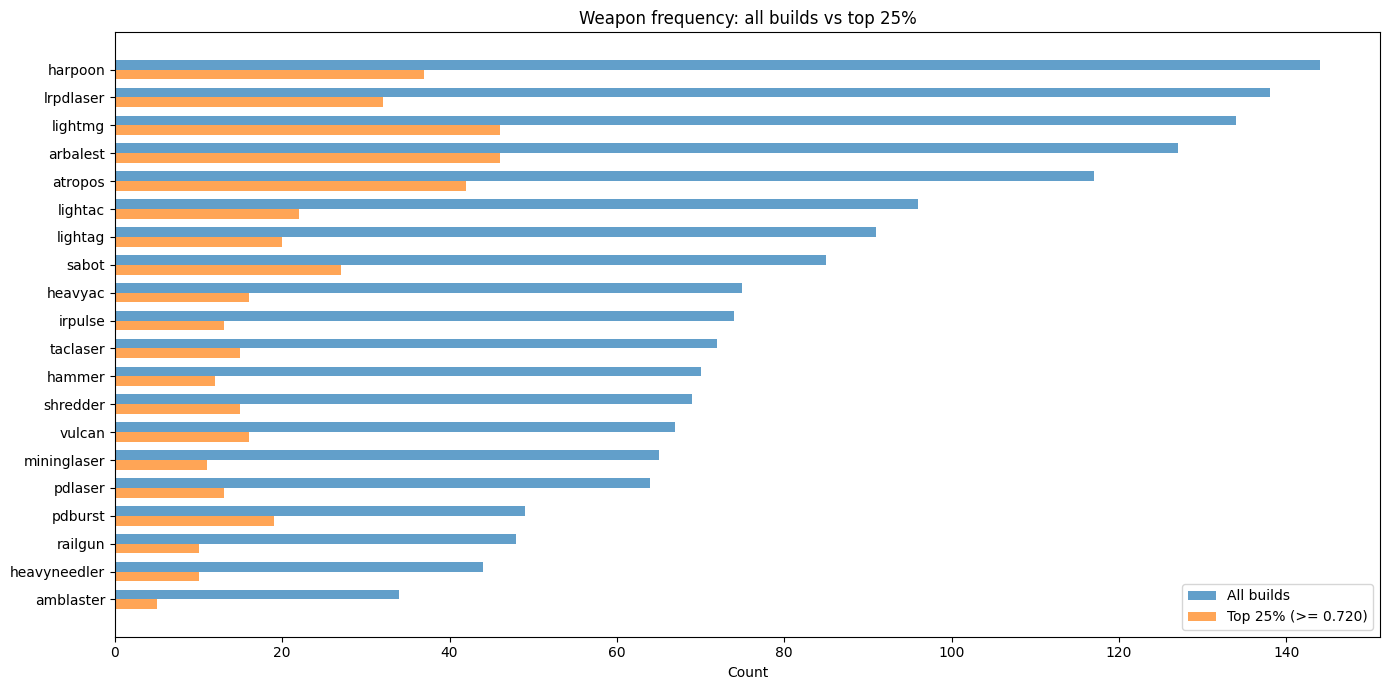


Weapon enrichment in top 25% (n=79):
  = harpoon                    6.7% all ->  6.9% top  [1.02x]
  = lrpdlaser                  6.4% all ->  5.9% top  [0.92x]
  + lightmg                    6.3% all ->  8.5% top  [1.36x]
  + arbalest                   5.9% all ->  8.5% top  [1.44x]
  + atropos                    5.5% all ->  7.8% top  [1.43x]
  = lightac                    4.5% all ->  4.1% top  [0.91x]
  = lightag                    4.2% all ->  3.7% top  [0.87x]
  + sabot                      4.0% all ->  5.0% top  [1.26x]
  = heavyac                    3.5% all ->  3.0% top  [0.85x]
  - irpulse                    3.5% all ->  2.4% top  [0.70x]
  = taclaser                   3.4% all ->  2.8% top  [0.83x]
  - hammer                     3.3% all ->  2.2% top  [0.68x]
  = shredder                   3.2% all ->  2.8% top  [0.86x]
  = vulcan                     3.1% all ->  3.0% top  [0.95x]
  - mininglaser                3.0% all ->  2.0% top  [0.67x]


In [3]:
all_weapons = Counter()
top_weapons = Counter()

for e, is_top in zip(completed_entries, top_mask):
    ws = [w for w in e["build"]["weapon_assignments"].values() if w is not None]
    all_weapons.update(ws)
    if is_top:
        top_weapons.update(ws)

top_20 = all_weapons.most_common(20)
names = [w for w, _ in top_20]
all_counts = [all_weapons[w] for w in names]
top_counts = [top_weapons.get(w, 0) for w in names]

fig, ax = plt.subplots(figsize=(14, 7))
x = np.arange(len(names))
width = 0.35
ax.barh(x - width/2, all_counts, width, label="All builds", alpha=0.7)
ax.barh(x + width/2, top_counts, width,
        label=f"Top 25% (>= {top_25_threshold:.3f})", alpha=0.7)
ax.set_yticks(x)
ax.set_yticklabels(names)
ax.set_xlabel("Count")
ax.set_title("Weapon frequency: all builds vs top 25%")
ax.legend()
ax.invert_yaxis()
plt.tight_layout()
plt.show()

total_all = sum(all_weapons.values())
total_top = sum(top_weapons.values()) or 1
print(f"\nWeapon enrichment in top 25% (n={n_top}):")
for w in names[:15]:
    frac_all = all_weapons[w] / total_all
    frac_top = top_weapons.get(w, 0) / total_top
    enrichment = frac_top / frac_all if frac_all > 0 else 0
    arrow = "+" if enrichment > 1.2 else ("-" if enrichment < 0.8 else "=")
    print(f"  {arrow} {w:<25s} {frac_all:5.1%} all -> {frac_top:5.1%} top  [{enrichment:.2f}x]")

## Hullmod Popularity

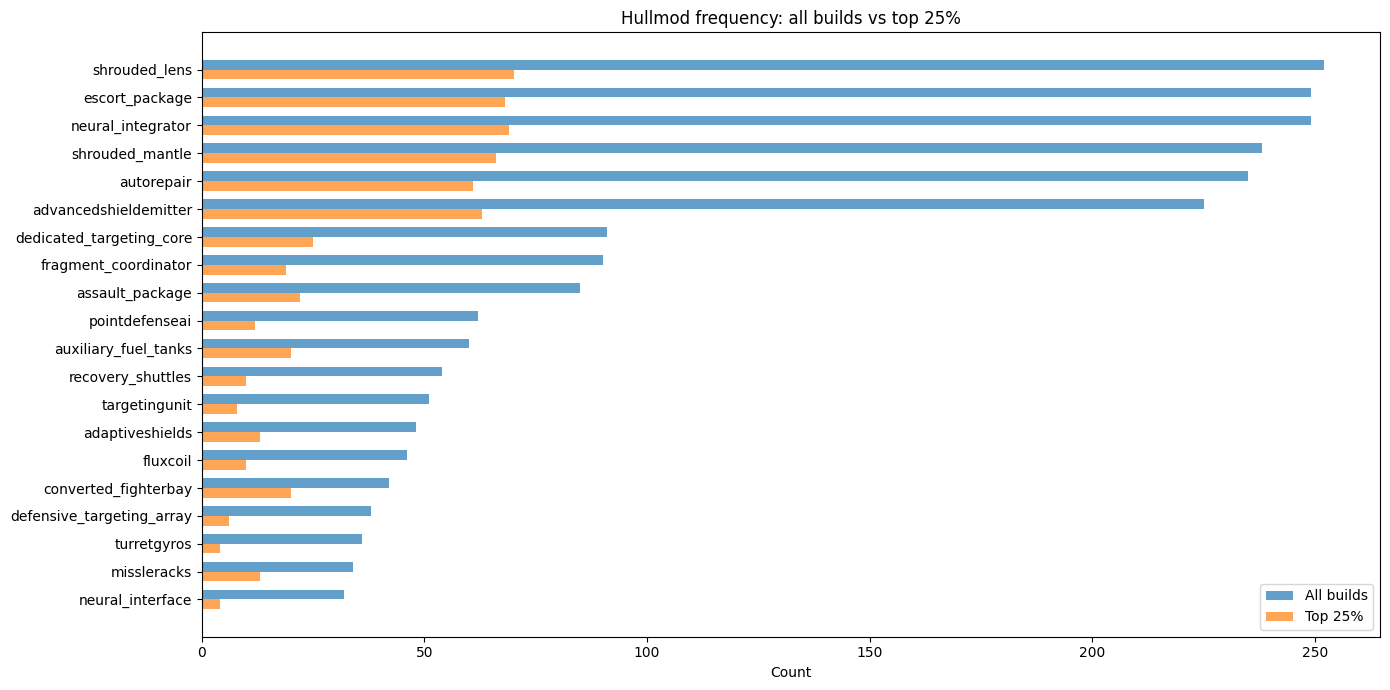


Hullmod enrichment in top 25% (n=79):
  = shrouded_lens                   81% all ->  89% top  [1.10x]
  = escort_package                  80% all ->  86% top  [1.08x]
  = neural_integrator               80% all ->  87% top  [1.10x]
  = shrouded_mantle                 76% all ->  84% top  [1.10x]
  = autorepair                      75% all ->  77% top  [1.03x]
  = advancedshieldemitter           72% all ->  80% top  [1.11x]
  = dedicated_targeting_core        29% all ->  32% top  [1.09x]
  = fragment_coordinator            29% all ->  24% top  [0.84x]
  = assault_package                 27% all ->  28% top  [1.03x]
  - pointdefenseai                  20% all ->  15% top  [0.77x]
  + auxiliary_fuel_tanks            19% all ->  25% top  [1.32x]
  - recovery_shuttles               17% all ->  13% top  [0.73x]
  - targetingunit                   16% all ->  10% top  [0.62x]
  = adaptiveshields                 15% all ->  16% top  [1.07x]
  = fluxcoil                        15% all ->  13%

In [4]:
all_mods = Counter()
top_mods = Counter()

for e, is_top in zip(completed_entries, top_mask):
    mods = e["build"]["hullmods"]
    all_mods.update(mods)
    if is_top:
        top_mods.update(mods)

top_mods_list = all_mods.most_common(20)
mod_names = [m for m, _ in top_mods_list]
all_mod_counts = [all_mods[m] for m in mod_names]
top_mod_counts = [top_mods.get(m, 0) for m in mod_names]

fig, ax = plt.subplots(figsize=(14, 7))
x = np.arange(len(mod_names))
width = 0.35
ax.barh(x - width/2, all_mod_counts, width, label="All builds", alpha=0.7)
ax.barh(x + width/2, top_mod_counts, width, label="Top 25%", alpha=0.7)
ax.set_yticks(x)
ax.set_yticklabels(mod_names)
ax.set_xlabel("Count")
ax.set_title("Hullmod frequency: all builds vs top 25%")
ax.legend()
ax.invert_yaxis()
plt.tight_layout()
plt.show()

print(f"\nHullmod enrichment in top 25% (n={n_top}):")
for m in mod_names:
    frac_all = all_mods[m] / n_all
    frac_top = top_mods.get(m, 0) / n_top if n_top else 0
    enrichment = frac_top / frac_all if frac_all > 0 else 0
    arrow = "+" if enrichment > 1.2 else ("-" if enrichment < 0.8 else "=")
    print(f"  {arrow} {m:<30s} {frac_all:4.0%} all -> {frac_top:4.0%} top  [{enrichment:.2f}x]")

## Opponent Difficulty

Per-opponent win rate, HP differential, and mean duration across all builds
(including pruned trials, which contribute partial data).

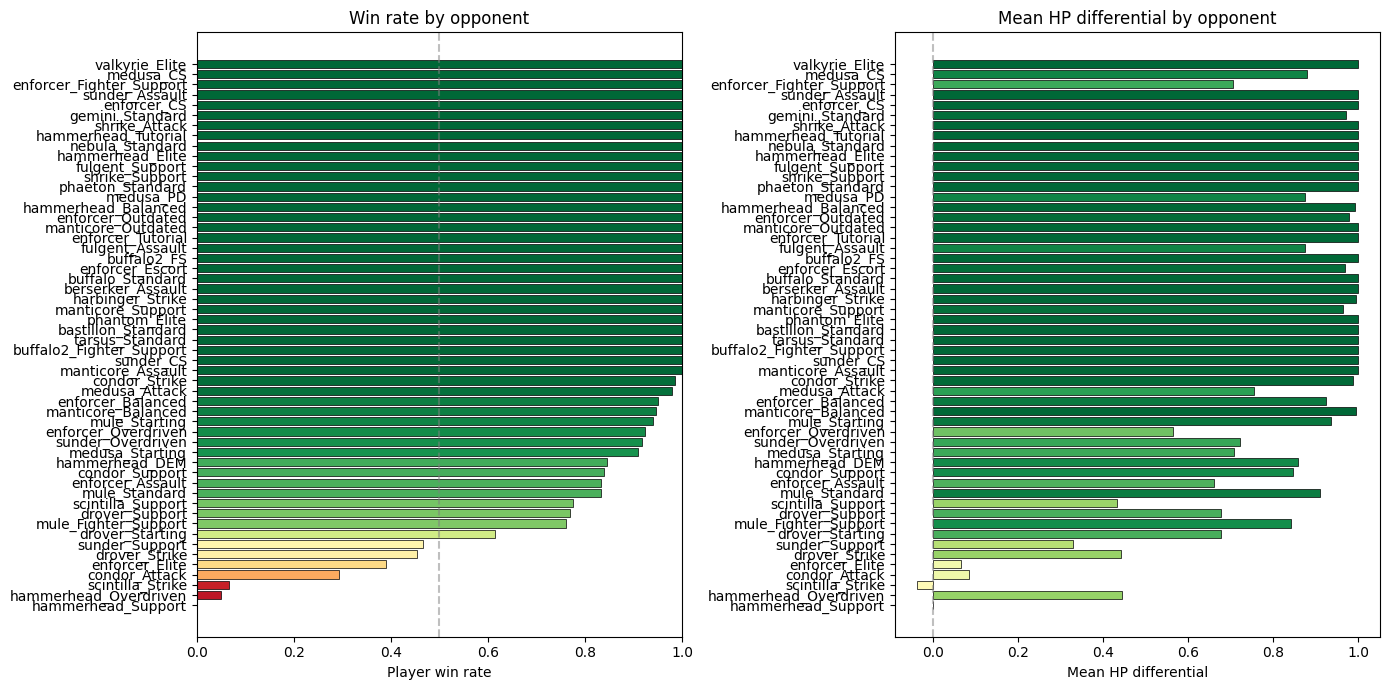

                opponent  total  win_rate  timeout_rate  mean_hp_diff  mean_duration
      hammerhead_Support     31     0.000         1.000         0.000        300.066
   hammerhead_Overdriven     20     0.050         0.950         0.446        298.152
        scintilla_Strike     15     0.067         0.533        -0.038        257.430
           condor_Attack    368     0.293         0.503         0.084        276.839
          enforcer_Elite     18     0.389         0.056         0.065        199.646
           drover_Strike     11     0.455         0.545         0.442        257.947
          sunder_Support    367     0.466         0.452         0.330        248.496
         drover_Starting     13     0.615         0.385         0.678        254.964
    mule_Fighter_Support    368     0.761         0.239         0.841        241.485
          drover_Support     13     0.769         0.231         0.677        213.284
       scintilla_Support    209     0.775         0.057         0

In [5]:
opponent_stats = {}
for e in eval_entries:
    for r in e["opponent_results"]:
        opp = r["opponent"]
        s = opponent_stats.setdefault(opp, {
            "wins": 0, "losses": 0, "timeouts": 0, "stops": 0,
            "durations": [], "hp_diffs": [],
        })
        winner = r["winner"]
        if winner == "PLAYER":
            s["wins"] += 1
        elif winner == "ENEMY":
            s["losses"] += 1
        elif winner == "TIMEOUT":
            s["timeouts"] += 1
        else:
            s["stops"] += 1
        s["durations"].append(r["duration_seconds"])
        s["hp_diffs"].append(r["hp_differential"])

rows = []
for opp, s in opponent_stats.items():
    total = s["wins"] + s["losses"] + s["timeouts"] + s["stops"]
    rows.append({
        "opponent": opp,
        "total": total,
        "win_rate": s["wins"] / total,
        "loss_rate": s["losses"] / total,
        "timeout_rate": s["timeouts"] / total,
        "stop_rate": s["stops"] / total,
        "mean_hp_diff": float(np.mean(s["hp_diffs"])),
        "mean_duration": float(np.mean(s["durations"])),
    })

opp_df = pd.DataFrame(rows).sort_values("win_rate", ascending=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 7))
colors_win = plt.cm.RdYlGn(opp_df["win_rate"])
axes[0].barh(opp_df["opponent"], opp_df["win_rate"], color=colors_win,
             edgecolor="black", linewidth=0.5)
axes[0].axvline(0.5, color="gray", linestyle="--", alpha=0.5)
axes[0].set_xlabel("Player win rate")
axes[0].set_title("Win rate by opponent")
axes[0].set_xlim(0, 1)

colors_hp = plt.cm.RdYlGn((opp_df["mean_hp_diff"] + 1) / 2)
axes[1].barh(opp_df["opponent"], opp_df["mean_hp_diff"], color=colors_hp,
             edgecolor="black", linewidth=0.5)
axes[1].axvline(0, color="gray", linestyle="--", alpha=0.5)
axes[1].set_xlabel("Mean HP differential")
axes[1].set_title("Mean HP differential by opponent")

plt.tight_layout()
plt.show()

print(opp_df[["opponent", "total", "win_rate", "timeout_rate",
              "mean_hp_diff", "mean_duration"]]
        .to_string(index=False, float_format="%.3f"))

## Flux Allocation

Scatter of vents × capacitors colored by fitness, plus top vs bottom
distributions.

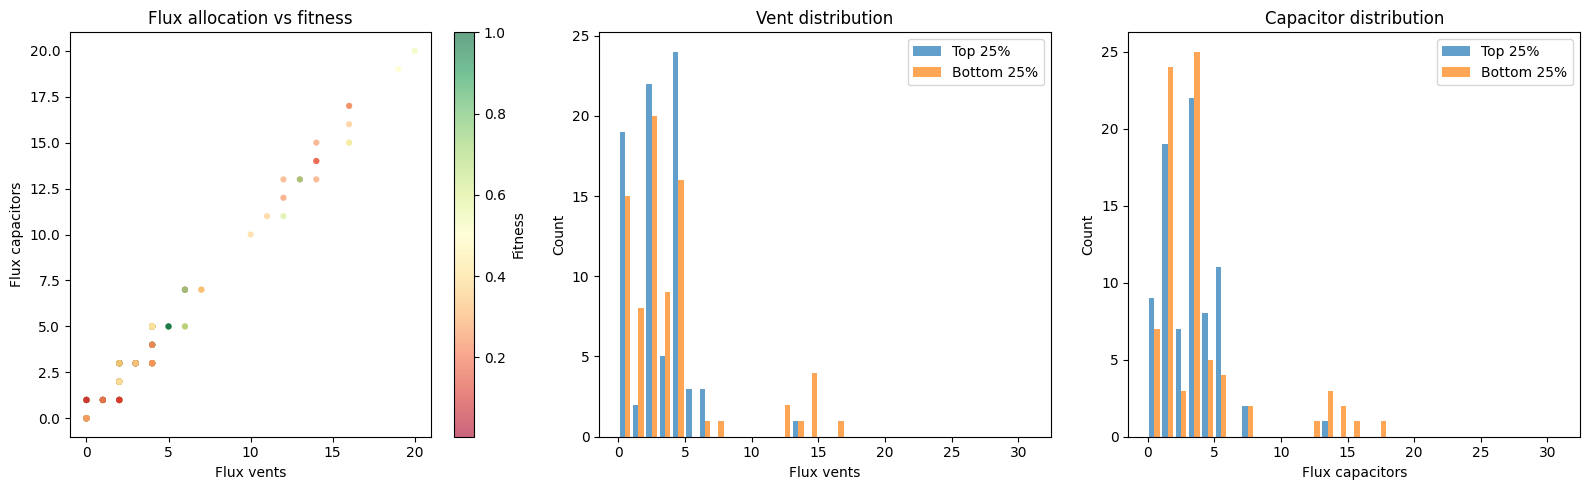

Top 25%    — vents: 2.6 mean  caps: 2.7 mean
Bottom 25% — vents: 3.3 mean  caps: 3.5 mean


In [6]:
vents = np.array([e["build"]["flux_vents"] for e in completed_entries])
caps = np.array([e["build"]["flux_capacitors"] for e in completed_entries])

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

sc = axes[0].scatter(vents, caps, c=fitness, cmap="RdYlGn", alpha=0.6,
                     s=20, edgecolors="none")
plt.colorbar(sc, ax=axes[0], label="Fitness")
axes[0].set_xlabel("Flux vents")
axes[0].set_ylabel("Flux capacitors")
axes[0].set_title("Flux allocation vs fitness")

vent_max = int(max(vents.max() if vents.size else 0, 30)) + 2
cap_max = int(max(caps.max() if caps.size else 0, 30)) + 2
axes[1].hist([vents[top_mask], vents[bot_mask]],
             bins=range(0, vent_max), label=["Top 25%", "Bottom 25%"], alpha=0.7)
axes[1].set_xlabel("Flux vents")
axes[1].set_ylabel("Count")
axes[1].set_title("Vent distribution")
axes[1].legend()

axes[2].hist([caps[top_mask], caps[bot_mask]],
             bins=range(0, cap_max), label=["Top 25%", "Bottom 25%"], alpha=0.7)
axes[2].set_xlabel("Flux capacitors")
axes[2].set_ylabel("Count")
axes[2].set_title("Capacitor distribution")
axes[2].legend()

plt.tight_layout()
plt.show()

if top_mask.any():
    print(f"Top 25%    — vents: {vents[top_mask].mean():.1f} mean  "
          f"caps: {caps[top_mask].mean():.1f} mean")
if bot_mask.any():
    print(f"Bottom 25% — vents: {vents[bot_mask].mean():.1f} mean  "
          f"caps: {caps[bot_mask].mean():.1f} mean")

## Fitness Clustering

How many builds reach the ceiling, and what do they share?

In [7]:
perfect = [e for e in completed_entries if e["fitness"] >= 0.999]
near_perfect = [e for e in completed_entries if 0.7 <= e["fitness"] < 0.999]
mediocre = [e for e in completed_entries if e["fitness"] < 0.3]

print(f"Perfect      (>=0.999):       {len(perfect)}")
print(f"Near-perfect (0.7-0.999):     {len(near_perfect)}")
print(f"Mediocre     (<0.3):          {len(mediocre)}")

if perfect:
    perfect_weapons = Counter()
    perfect_mods = Counter()
    for e in perfect:
        perfect_weapons.update(w for w in e["build"]["weapon_assignments"].values()
                               if w is not None)
        perfect_mods.update(e["build"]["hullmods"])

    print(f"\nMost common weapons across {len(perfect)} perfect builds:")
    for w, c in perfect_weapons.most_common(10):
        print(f"  {w:<25s} {c:4d}  ({100 * c / len(perfect):3.0f}% of perfect builds)")

    print(f"\nMost common hullmods in perfect builds:")
    for m, c in perfect_mods.most_common(10):
        print(f"  {m:<30s} {c:4d}  ({100 * c / len(perfect):3.0f}% of perfect builds)")

Perfect      (>=0.999):       7
Near-perfect (0.7-0.999):     78
Mediocre     (<0.3):          77

Most common weapons across 7 perfect builds:
  lightmg                      6  ( 86% of perfect builds)
  harpoon                      5  ( 71% of perfect builds)
  atropos                      4  ( 57% of perfect builds)
  lrpdlaser                    4  ( 57% of perfect builds)
  arbalest                     3  ( 43% of perfect builds)
  sabot                        2  ( 29% of perfect builds)
  mininglaser                  2  ( 29% of perfect builds)
  vulcan                       2  ( 29% of perfect builds)
  shredder                     2  ( 29% of perfect builds)
  lightac                      2  ( 29% of perfect builds)

Most common hullmods in perfect builds:
  shrouded_lens                     7  (100% of perfect builds)
  shrouded_mantle                   7  (100% of perfect builds)
  advancedshieldemitter             5  ( 71% of perfect builds)
  autorepair                     

## Parameter Importance (fANOVA)

Top parameters driving fitness, per Optuna's fANOVA evaluator.

Parameter                                Importance
---------------------------------------------------
hullmod_operations_center                    0.3280
hullmod_augmentedengines                     0.1097
flux_capacitors                              0.0548
flux_vents                                   0.0499
weapon_WS 002                                0.0423
weapon_WS 007                                0.0357
weapon_WS 008                                0.0354
weapon_WS 001                                0.0292
weapon_WS 005                                0.0286
weapon_WS 006                                0.0243
weapon_WS 003                                0.0242
weapon_WS 004                                0.0220
hullmod_shrouded_lens                        0.0208
hullmod_auxiliary_fuel_tanks                 0.0151
hullmod_targetingunit                        0.0114
hullmod_escort_package                       0.0110
hullmod_surveying_equipment                  0.0092
hullmod_seco

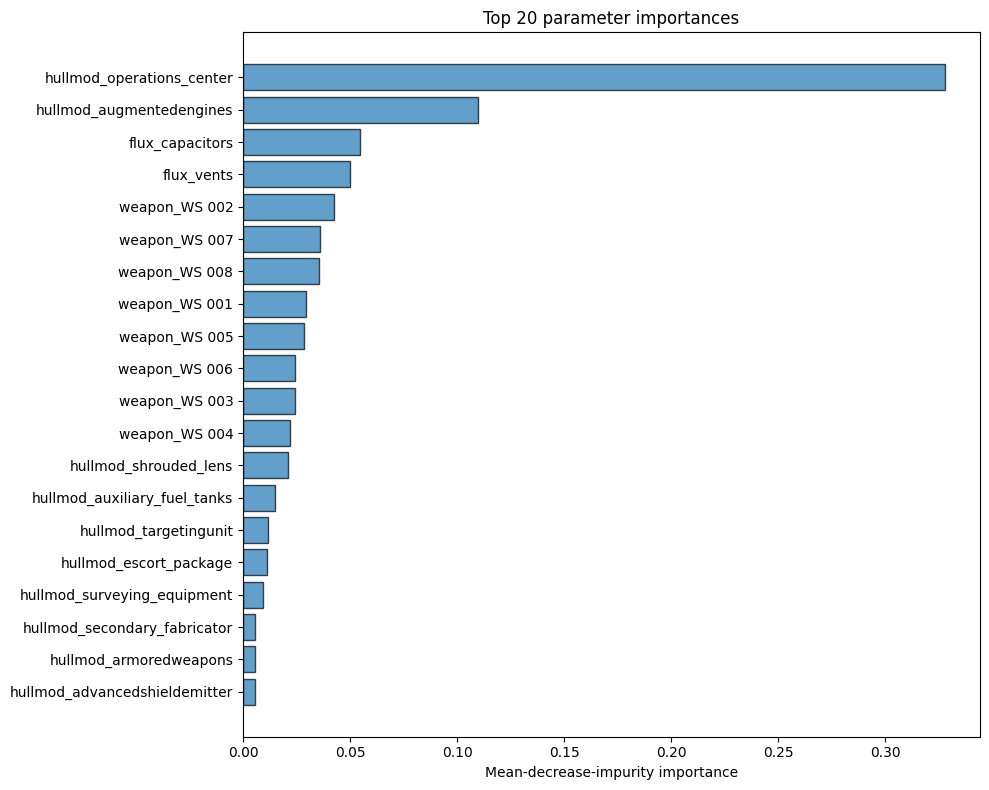

In [8]:
# MeanDecreaseImpurity is an RF-based importance that runs in ~seconds, unlike
# fANOVA which can take 10+ minutes on studies with many categorical params.
import optuna.importance as _imp

try:
    importances = _imp.get_param_importances(
        study, evaluator=_imp.MeanDecreaseImpurityImportanceEvaluator(),
    )
    sorted_items = sorted(importances.items(), key=lambda x: x[1], reverse=True)

    col_name = 40
    col_val = 10
    print(f"{'Parameter':<{col_name}} {'Importance':>{col_val}}")
    print("-" * (col_name + col_val + 1))
    for name, imp in sorted_items[:20]:
        print(f"{name:<{col_name}} {imp:>{col_val}.4f}")

    names = [p for p, _ in sorted_items[:20]]
    values = [v for _, v in sorted_items[:20]]

    fig, ax = plt.subplots(figsize=(10, 8))
    ax.barh(range(len(names)), values, edgecolor="black", alpha=0.7)
    ax.set_yticks(range(len(names)))
    ax.set_yticklabels(names)
    ax.set_xlabel("Mean-decrease-impurity importance")
    ax.set_title("Top 20 parameter importances")
    ax.invert_yaxis()
    plt.tight_layout()
    plt.show()
except Exception as exc:
    print(f"Importance analysis failed: {exc}")